# 06_08_plot_light_curve_using_csv

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ccdproc, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name=version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ysfitsutilpy, ysphotutilpy, ccdproc, aplpy, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is being installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module astroquery is installed
**** module photutils is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module ccdproc is installed
**** module aplpy is installed
**** module version_information is installed
This notebook was generated at 2024-06-08 22:52:32 (KST = GMT+0900) 
0 Python     3.11.5 64bit [GCC 11.2.0]
1 IPython    8.20.0
2 OS         Linux 5.15.0 107 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.1
5 matplotlib 3.8.4
6 scipy      1.13.0
7 astropy    5.3.4
8 astroquery 0.4.6
9 photutils  1.6.0
10 ysfitsutilpy (Pillow 8.4.0 (/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages), Requirement.parse('pillow>=9.0.1'), {'scikit-image'})
11 ysphotutilpy (Pillow 8.4.0 (/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/si

### import modules

In [2]:
#%%
from glob import glob
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ccdproc import combine, ccd_process, CCDData

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.wcs import WCS
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import astropy.units as u

import ysfitsutilpy as yfu
import ysphotutilpy as ypu

import _astro_utilities
import _Python_utilities
import _tool_visualization

from astropy.nddata import Cutout2D
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clip, sigma_clipped_stats
from photutils.centroids import centroid_com

from photutils.aperture import CircularAperture as CAp
from photutils.aperture import CircularAnnulus as CAn
from photutils.aperture import aperture_photometry as apphot

In [3]:
#%%
#######################################################
# read all files in base directory for processing
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_1bin")
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "GSON300_STF-8300M_-_1bin")

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

mas1 = [x for x in DOINGDIRs if "CAL-BDF" in str(x)]
mas1 = mas1[0]/ _astro_utilities.master_dir
print ("mas1: ", format(mas1))

DOINGDIRs = sorted([x for x in DOINGDIRs if "_LIGHT_" in str(x)])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

# filter_str = '2023-12-'
# DOINGDIRs = [x for x in DOINGDIRs if filter_str in x]
# remove = 'BIAS'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'DARK'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'FLAT'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
print ("DOINGDIRs: ", DOINGDIRs)
print ("len(DOINGDIRs): ", len(DOINGDIRs))
#######################################################

DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/-_CAL-BDF_-_2019-08-28_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TOI-1859B_LIGHT_-_2024-05-09_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TOI-2583Ab_LIGHT_-_2024-05-28_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TRES-4B_LIGHT_-_2024-05-12_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/WASP-135B_LIGHT_-_2024-05-13_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/WASP-24B_LIGHT_-_2024-05-14_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/WASP-24B_LIGHT_-_2024-05-21_-_GSON300_STF-8300M_-_1bin')]
len(D

In [4]:
DOINGDIRs = DOINGDIRs[0:1]
print("DOINGDIRs:", DOINGDIRs)

DOINGDIRs: [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin')]


In [5]:
#####################################################################
# Observed location
LOCATION = dict(lon=127.005, lat=37.308889, elevation=101)
Suwon = location = EarthLocation(lon=127.005 * u.deg, 
                                 lat=37.308889 * u.deg, 
                                 height=101 * u.m)
observatory_code = "P64"

# Used for any `astropy.SkyCoord` object:
SKYC_KW = dict(unit=u.deg, frame='icrs')

#######################################################
# Initial guess of FWHM in pixel
FWHM_INIT = 6

# Photometry parameters
R_AP = 1.5*FWHM_INIT # Aperture radius
R_IN = 4*FWHM_INIT   # Inner radius of annulus
R_OUT = 6*FWHM_INIT  # Outer radius of annulus

Mag_UP = 16
#######################################################

In [6]:
for DOINGDIR in DOINGDIRs[:1] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)

    DIFFPRESULTDIR = DOINGDIR / _astro_utilities.Diff_Phot_dir

    # print(str(DOINGDIR.parts[-2]) == "RiLA600_STX-16803_-_1bin")
    # if str(DOINGDIR.parts[-2]) == "RiLA600_STX-16803_-_1bin" :
    #     DOINGDIR = DOINGDIR / _astro_utilities.REDUC_nightsky_dir
    # print(str(DOINGDIR.parts[-2]) == "GSON300_STF-8300M_-_1bin")
    # if str(DOINGDIR.parts[-2]) == "GSON300_STF-8300M_-_1bin" :
    #     DOINGDIR = DOINGDIR / _astro_utilities.reduced_dir

    # if not INSTRESULTDIR.exists():
    #     os.makedirs("{}".format(str(INSTRESULTDIR)))
    #     print("{} is created...".format(str(INSTRESULTDIR)))
    
    csv_in_dir = sorted(list(DIFFPRESULTDIR.glob('*result_photometry.csv')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(csv_in_dir))
    

DOINGDIR /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin
len(fits_in_dir) 10


In [7]:
df = pd.DataFrame()
for fpath in csv_in_dir[:]:
    fpath = Path(fpath)
    print(f"starting... {fpath}")
    df_csv = pd.read_csv(fpath)
    df = pd.concat([df, df_csv], axis=0)
    

starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-15-55_120sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-18-15_180sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-27-46_120sec_GSON300_STF-8300M_19c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_L

In [8]:
df_csv

,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,...,mag_ann,merr_ann,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,y0,R_magnitude
0,0,1,3230.430247,7.091748,2.883237e+06,11506.756624,190.158966,1312.0,7.0,-44876.323289,...,NaN,-0.027935,302.409854,65.480707,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
1,1,2,2402.315608,8.261045,3.027306e+06,11630.488728,189.937274,1331.0,16.0,67706.781103,...,-12.076580,0.018854,302.917828,65.488679,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,13.703858
2,2,3,2092.753657,7.644450,2.919925e+06,11640.993740,188.296555,1319.0,13.0,-42346.869044,...,NaN,-0.029687,303.107761,65.491470,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
3,3,4,2419.931420,15.156604,2.947067e+06,11609.641519,184.283234,1506.0,22.0,-7226.963116,...,NaN,-0.172103,302.907175,65.486766,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
4,4,5,1778.047226,16.654421,2.982492e+06,11642.687826,189.782990,1557.0,10.0,19788.936274,...,-10.741056,0.063289,303.301066,65.491600,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.039383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,635,636,1516.169617,2497.993717,2.816888e+06,11313.446062,179.355315,2211.0,11.0,-62033.025864,...,NaN,-0.019119,303.501543,64.861224,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
636,636,637,2326.174277,2500.428151,2.902132e+06,11324.660947,181.099064,2131.0,11.0,20356.786787,...,-10.771773,0.059205,303.015618,64.854515,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.008666
637,637,638,38.596710,2510.478815,2.890561e+06,10916.394291,178.586118,1680.0,16.0,112676.527617,...,-12.629584,0.010815,304.388422,64.864872,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,13.150855
638,638,639,2506.754902,2515.192410,2.903128e+06,11345.981445,183.987591,1533.0,15.0,15927.362238,...,-10.505360,0.077482,302.907600,64.849168,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.275079


In [9]:
print(len(df_csv))
df_csv
print(len(df))
df

640
3701


,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,...,mag_ann,merr_ann,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,y0,R_magnitude
0,0,1,757.945455,7.014331,5.023550e+06,20470.721169,242.859143,1294.0,17.0,-185613.772798,...,NaN,-0.008842,303.928091,65.502484,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,NaN
1,1,2,3217.832753,7.677769,5.198768e+06,20379.065058,248.691427,1318.0,15.0,12927.847041,...,-10.278816,0.129061,302.418242,65.482843,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,16.094336
2,2,3,62.881112,10.153413,5.193644e+06,19627.120289,253.348173,1383.0,9.0,199149.966591,...,-13.247951,0.008367,304.354947,65.504249,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,13.125201
3,3,4,1918.605644,11.208148,5.404049e+06,20555.662783,255.661478,1411.0,11.0,173269.773713,...,-13.096807,0.009772,303.215560,65.494250,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,13.276345
4,4,5,192.491343,12.513923,5.566657e+06,19971.568099,250.495086,1442.0,11.0,484511.540394,...,-14.213260,0.003520,304.275382,65.503268,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,12.159892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,635,636,1516.169617,2497.993717,2.816888e+06,11313.446062,179.355315,2211.0,11.0,-62033.025864,...,NaN,-0.019119,303.501543,64.861224,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
636,636,637,2326.174277,2500.428151,2.902132e+06,11324.660947,181.099064,2131.0,11.0,20356.786787,...,-10.771773,0.059205,303.015618,64.854515,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.008666
637,637,638,38.596710,2510.478815,2.890561e+06,10916.394291,178.586118,1680.0,16.0,112676.527617,...,-12.629584,0.010815,304.388422,64.864872,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,13.150855
638,638,639,2506.754902,2515.192410,2.903128e+06,11345.981445,183.987591,1533.0,15.0,15927.362238,...,-10.505360,0.077482,302.907600,64.849168,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.275079


In [10]:
df.columns

Index(['Unnamed: 0', 'id', 'xcenter', 'ycenter', 'aperture_sum', 'msky',
       'sky_std', 'nsky', 'nrej', 'flux_star', 'flux_err', 'mag_ann',
       'merr_ann', 'RAJ2000', 'DEJ2000', 'filename', 't_start', 't_expos',
       't_middle', 'y0', 'R_magnitude'],
      dtype='object')

In [11]:
df.drop(columns=['Unnamed: 0', 'id'], axis=0)
# df.drop(['Unnamed: 0', 'id'], axis=0)
df.reset_index(inplace=True)
df

,index,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,...,mag_ann,merr_ann,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,y0,R_magnitude
0,0,0,1,757.945455,7.014331,5.023550e+06,20470.721169,242.859143,1294.0,17.0,...,NaN,-0.008842,303.928091,65.502484,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,NaN
1,1,1,2,3217.832753,7.677769,5.198768e+06,20379.065058,248.691427,1318.0,15.0,...,-10.278816,0.129061,302.418242,65.482843,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,16.094336
2,2,2,3,62.881112,10.153413,5.193644e+06,19627.120289,253.348173,1383.0,9.0,...,-13.247951,0.008367,304.354947,65.504249,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,13.125201
3,3,3,4,1918.605644,11.208148,5.404049e+06,20555.662783,255.661478,1411.0,11.0,...,-13.096807,0.009772,303.215560,65.494250,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,13.276345
4,4,4,5,192.491343,12.513923,5.566657e+06,19971.568099,250.495086,1442.0,11.0,...,-14.213260,0.003520,304.275382,65.503268,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,-26.373152,12.159892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,635,635,636,1516.169617,2497.993717,2.816888e+06,11313.446062,179.355315,2211.0,11.0,...,NaN,-0.019119,303.501543,64.861224,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,NaN
3697,636,636,637,2326.174277,2500.428151,2.902132e+06,11324.660947,181.099064,2131.0,11.0,...,-10.771773,0.059205,303.015618,64.854515,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.008666
3698,637,637,638,38.596710,2510.478815,2.890561e+06,10916.394291,178.586118,1680.0,16.0,...,-12.629584,0.010815,304.388422,64.864872,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,13.150855
3699,638,638,639,2506.754902,2515.192410,2.903128e+06,11345.981445,183.987591,1533.0,15.0,...,-10.505360,0.077482,302.907600,64.849168,Qatar-1b_LIGHT_R_2024-05-29-13-02-48_120sec_GS...,2024-05-29T13:02:48.428,120.0,2024-05-29T13:03:48.428,-25.780439,15.275079


In [12]:
targ_name = "Qatar-1b"

targ_sky = SkyCoord(["20:13:31.6176 65:09:43.490"], 
                    frame="fk5", unit=(u.hourangle, u.deg)
                    )

targ_sky
targ_sky.ra.value[0]
type(targ_sky.ra.value[0])


numpy.float64

In [14]:
print(df.columns)

df_star = df.loc[(df["RAJ2000"] > targ_sky.ra.value[0]*0.9999) \
                 & (df["RAJ2000"] < targ_sky.ra.value[0]*1.0001) \
                 & (df["DEJ2000"] > targ_sky.dec.value[0]*0.9999)\
                 & (df["DEJ2000"] < targ_sky.dec.value[0]*1.0001)]

df_star
df_star[['t_middle', 'R_magnitude']]

Index(['index', 'Unnamed: 0', 'id', 'xcenter', 'ycenter', 'aperture_sum',
       'msky', 'sky_std', 'nsky', 'nrej', 'flux_star', 'flux_err', 'mag_ann',
       'merr_ann', 'RAJ2000', 'DEJ2000', 'filename', 't_start', 't_expos',
       't_middle', 'y0', 'R_magnitude'],
      dtype='object')


,t_middle,R_magnitude
234,2024-05-29T12:08:14.152,12.432431
620,2024-05-29T12:16:55.657,12.507071
940,2024-05-29T12:19:45.345,12.227332
1223,2024-05-29T12:28:46.672,12.366634
1455,2024-05-29T12:31:52.771,14.157162
1693,2024-05-29T12:40:31.267,12.541117
2022,2024-05-29T12:43:23.978,12.544814
2434,2024-05-29T12:52:18.749,12.480940
2857,2024-05-29T12:55:06.617,12.280218
3387,2024-05-29T13:03:48.428,14.144455


In [365]:
# import astroquery.gaia

# num_stars = 10

# query = f"""SELECT TOP {num_stars} dr3.ra, dr3.dec, dr3.phot_g_mean_mag, dr3.distance_gspphot
# FROM gaiadr3.gaia_source as dr3
# ORDER BY dr3.distance_gspphot ASC
# """

# job = astroquery.gaia.Gaia.launch_job(query)

# table = job.get_results()

# print(table)

In [386]:
from astroquery.simbad import Simbad

print(df["RA2000"][10], df["DEC2000"][10])
print(type(df["RA2000"][10]), type(df["DEC2000"][10]))

result_table = Simbad.query_region(SkyCoord(df["RA2000"][10], df["DEC2000"][10], unit="deg", frame='fk5'),
                                   radius='0d10m00s')
print(result_table)

303.53983406 65.49361985
<class 'numpy.float64'> <class 'numpy.float64'>
          MAIN_ID                  RA      ... SCRIPT_NUMBER_ID
                                "h:m:s"    ...                 
---------------------------- ------------- ... ----------------
         NVSS J201433+652718   20 14 33.55 ...                1
     ZTF J201411.60+653412.0   20 14 11.61 ...                1
               TYC 4240-38-1 20 13 38.1316 ...                1
     ZTF J201409.69+652418.6   20 14 09.69 ...                1
Gaia DR3 2244981471502902272 20 14 01.3826 ...                1
Gaia DR3 2244975527266281472 20 13 33.9946 ...                1
      GALEX J201427.2+652420 20 14 27.2167 ...                1
Gaia DR3 2244975149306762240 20 13 50.8014 ...                1
             TYC 4240-1312-1 20 13 50.7722 ...                1
Gaia DR3 2244975149306762112 20 13 50.6181 ...                1
              TYC 4240-242-1 20 13 07.7674 ...                1
              TYC 4240-912-1 20

In [387]:
from urllib.parse import urlencode
from astropy.io import fits
# object_main_id = result_table[0]['MAIN_ID'].decode('ascii')
# object_coords = SkyCoord(ra=result_table['RA'], dec=result_table['DEC'], 
#                         unit=(u.hourangle, u.deg), frame='icrs')
object_main_id = result_table[0]['MAIN_ID']
object_coords_img = SkyCoord(df["RA2000"][10], df["DEC2000"][10], 
                        unit=(u.deg, u.deg), frame='fk5')
print(object_coords_img)
object_coords_img.ra.to(u.hourangle).value
# object_coords[0].ra.value

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (303.53983406, 65.49361985)>


20.235988937333335

In [388]:
from urllib.parse import urlencode
from astropy.io import fits
# object_main_id = result_table[0]['MAIN_ID'].decode('ascii')
# object_coords_sim = SkyCoord(ra=result_table['RA'], dec=result_table['DEC'], 
#                         unit=(u.hourangle, u.deg), frame='icrs')
object_coords_sim = SkyCoord(ra=result_table['RA'], dec=result_table['DEC'], 
                        unit=(u.hourangle, u.deg), frame='fk5')
object_main_id = result_table[0]['MAIN_ID']


query_params = { 
     'hips': 'DSS', 
     'object': object_main_id, 
     'ra': object_coords_sim[0].ra.value, 
     'dec': object_coords_sim[0].dec.value, 
    #  'ra': object_coords.ra.value, 
    #  'dec': object_coords.dec.value, 
     'fov': (8 * u.arcmin).to(u.deg).value, 
     'width': 2000, 
     'height': 2000 
 }                                                                                               
url = f'http://alasky.u-strasbg.fr/hips-image-services/hips2fits?{urlencode(query_params)}' 
hdul = fits.open(url)   

In [389]:
hdul.info()

Filename: /home/guitar79/.astropy/cache/download/url/4e1fb52ac653d7c4e9df03d62bb09d80/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (2000, 2000)   int16   


In [390]:
print(object_coords_sim)
print(object_coords_img)

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    [(303.63979167, 65.45525   ), (303.548375  , 65.57002778),
     (303.40888167, 65.43946639), (303.540375  , 65.40519444),
     (303.50576083, 65.58268778), (303.39164417, 65.42615139),
     (303.61340292, 65.4057675 ), (303.4616725 , 65.38445889),
     (303.46155083, 65.38443194), (303.46090875, 65.38426861),
     (303.28236417, 65.53456056), (303.26735042, 65.52422306),
     (303.26083958, 65.54043028), (303.18846583, 65.4775775 ),
     (303.18383667, 65.53560667)]>
<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (303.53983406, 65.49361985)>


In [391]:
print(object_coords_img.transform_to('icrs'))
print(object_coords_img)

<SkyCoord (ICRS): (ra, dec) in deg
    (303.53982562, 65.49361385)>
<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (303.53983406, 65.49361985)>


INFO: Auto-setting vmin to  2.302e+03 [aplpy.core]
INFO: Auto-setting vmax to  9.948e+03 [aplpy.core]


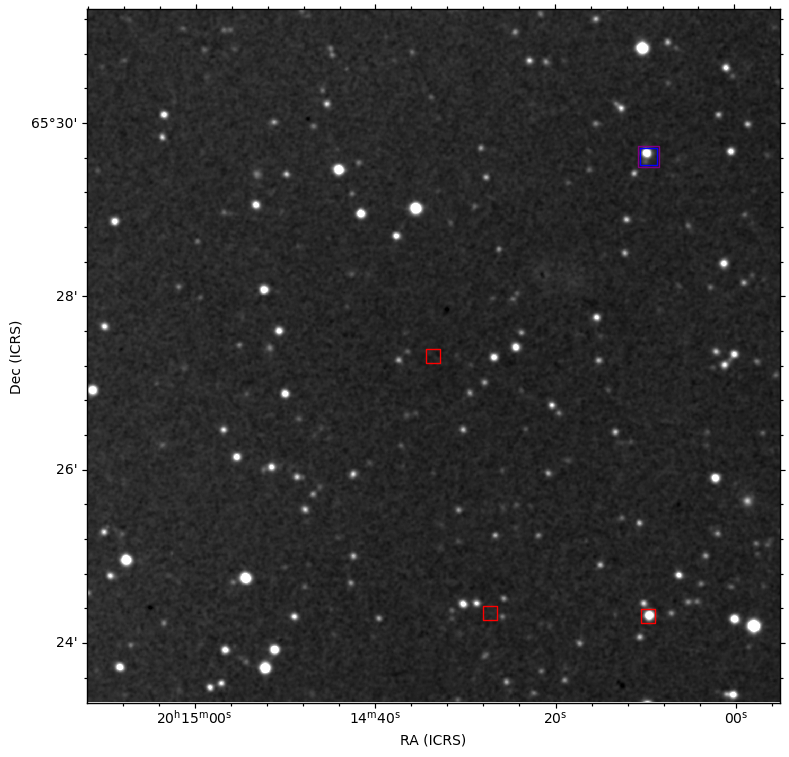

In [393]:
import aplpy
gc = aplpy.FITSFigure(hdul)                                                                     
gc.show_grayscale()                                                                             

gc.show_markers(object_coords_sim.ra, object_coords_sim.dec, edgecolor='red',
                 marker='s', s=10**2)
gc.show_markers(object_coords_img.ra, object_coords_img.dec, edgecolor='blue',
                 marker='s', s=12**2)         
# gc.show_markers(object_coords_img.transform_to('icrs').ra, object_coords_img.transform_to('icrs').dec, edgecolor='purple',
#                  marker='s', s=15**2)  
#gc.save('plot.png')

# 여기

In [345]:
from urllib.parse import urlencode
from urllib.parse import urlencode
from astropy.io import fits

object_coords_img = SkyCoord(df["RA2000"][10], df["DEC2000"][10], 
                            unit=(u.deg, u.deg), frame='fk5')
object_coords_img
object_coords_img.ra.to(u.hourangle).value
# object_coords[0].ra.value

20.292807779333337

In [13]:
ap_area  = apert.area
ap_area

254.46900494077323

/tmp/ipykernel_119037/454937046.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_set = plt.figure(figsize=(8, 5.5))


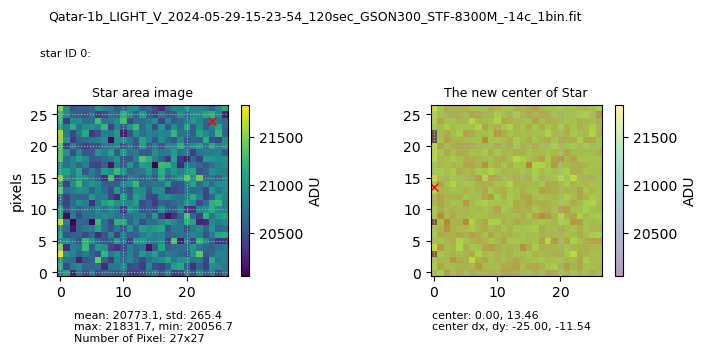

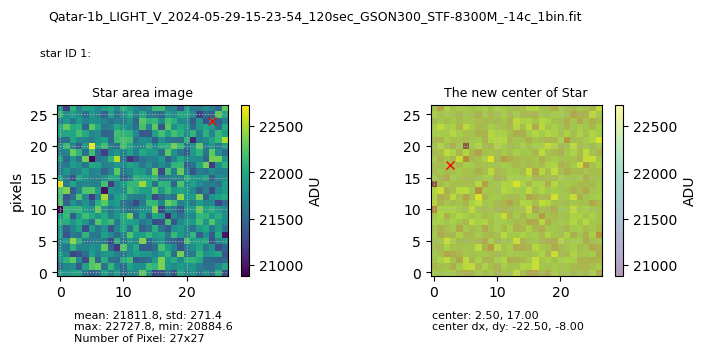

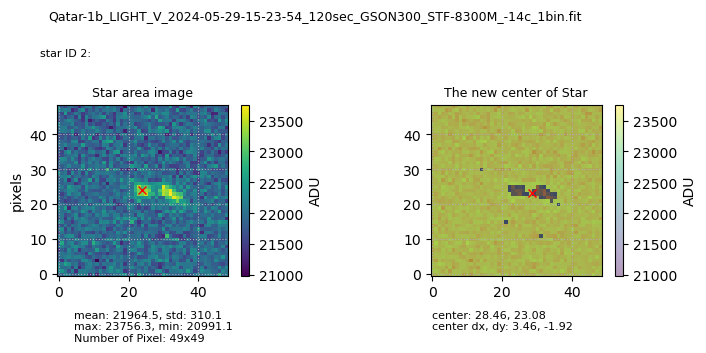

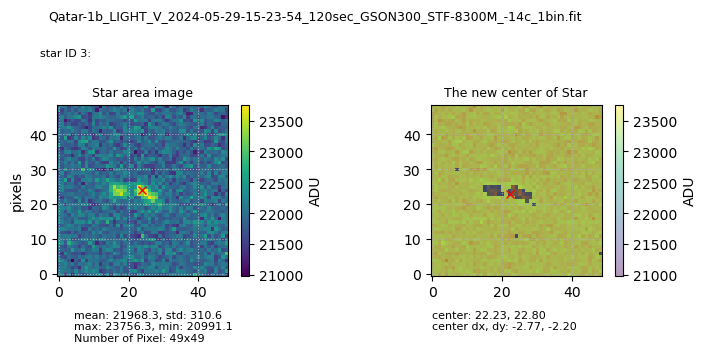

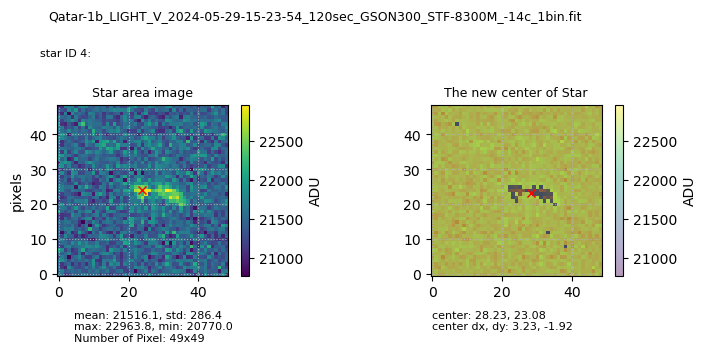

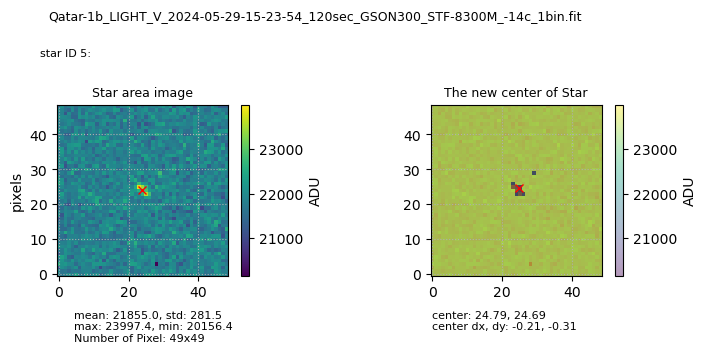

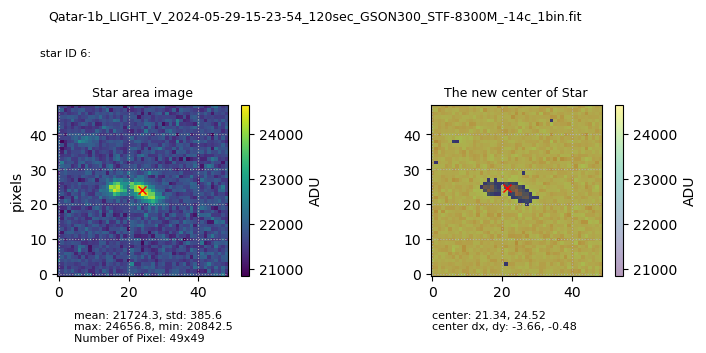

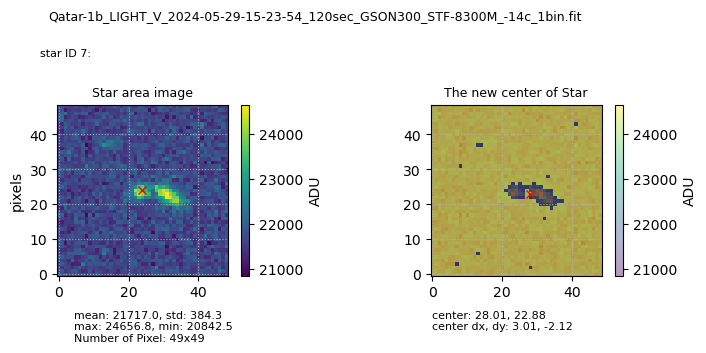

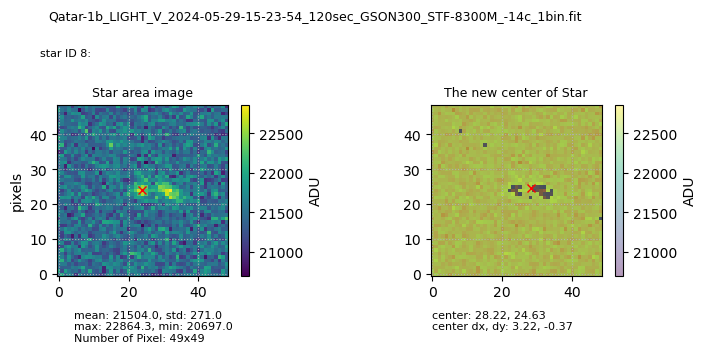

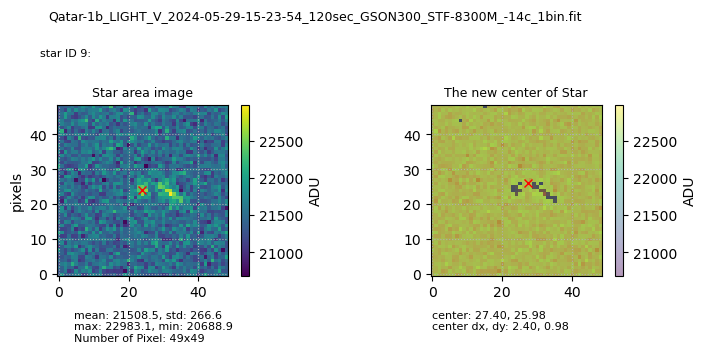

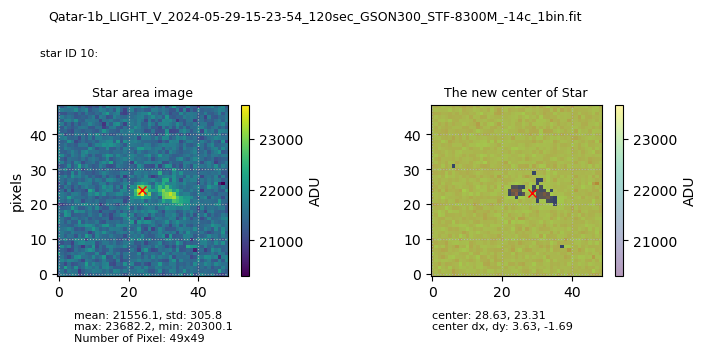

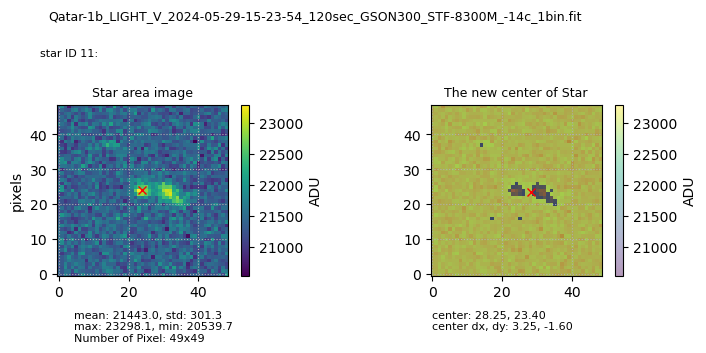

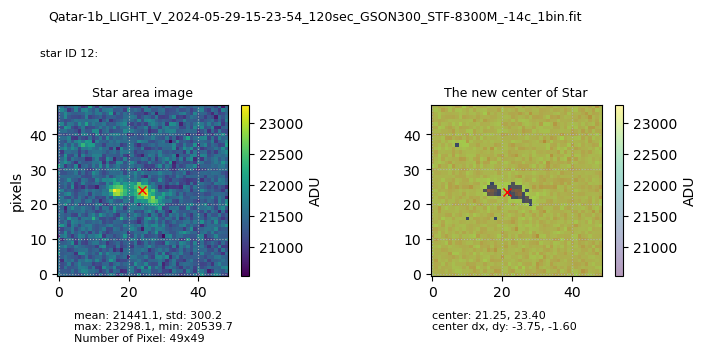

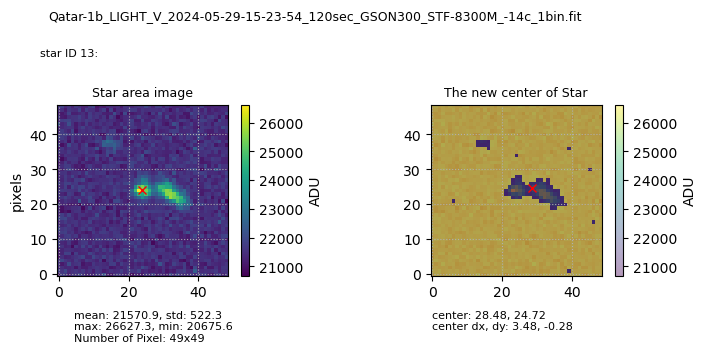

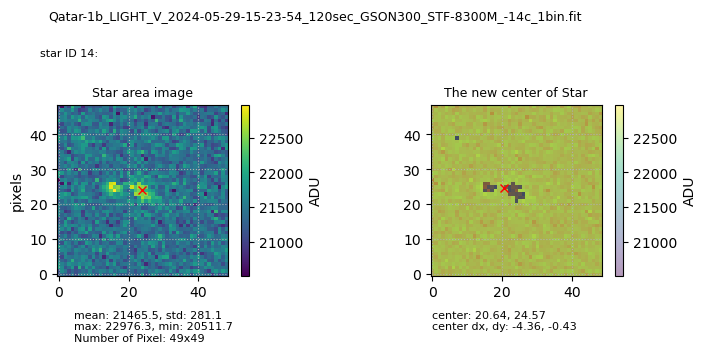

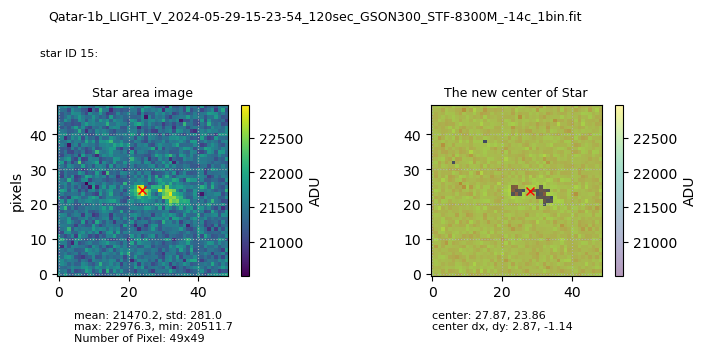

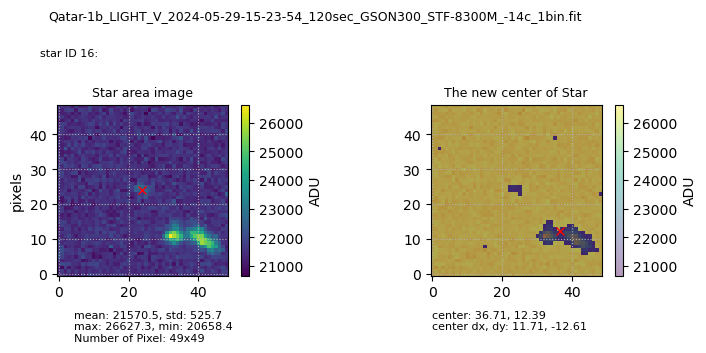

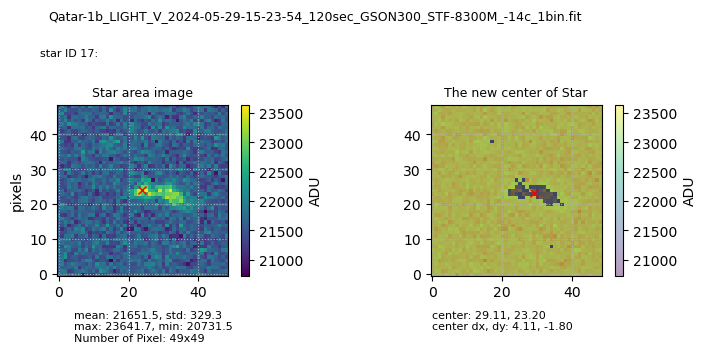

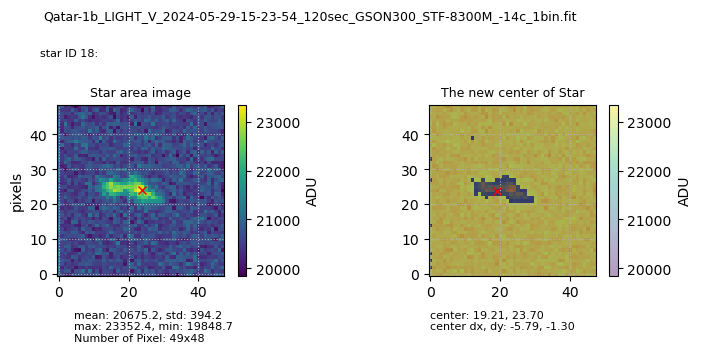

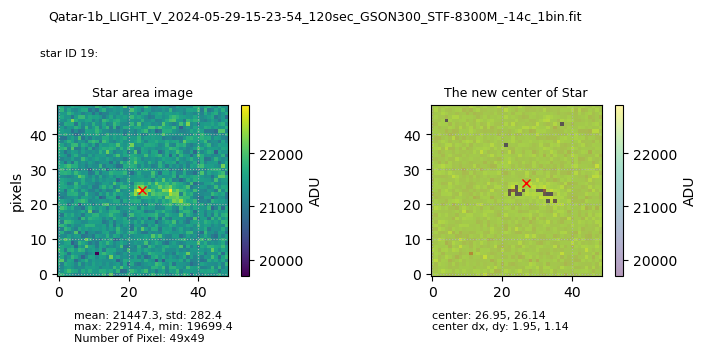

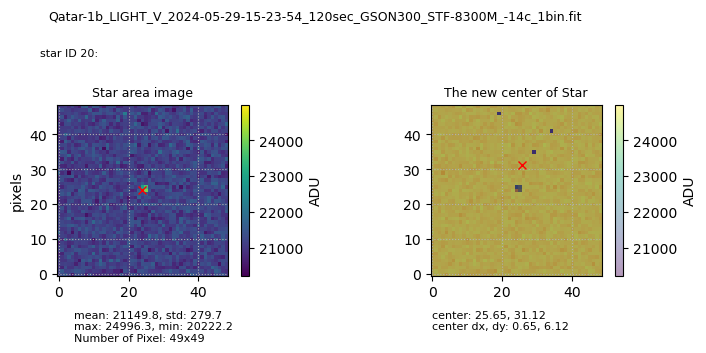

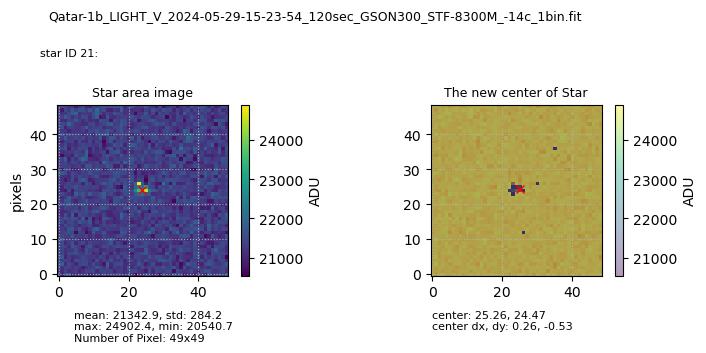

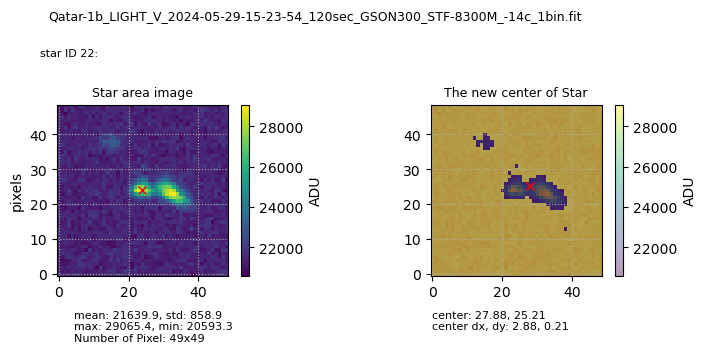

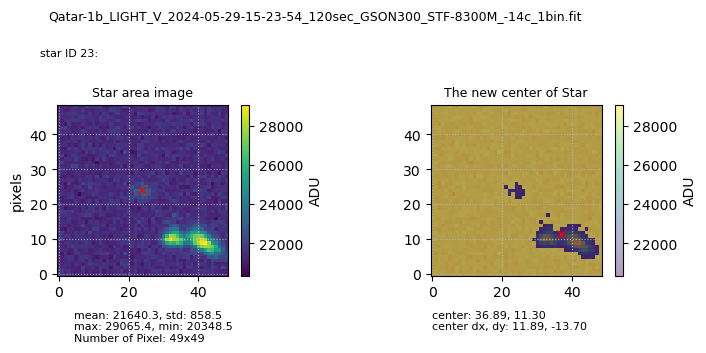

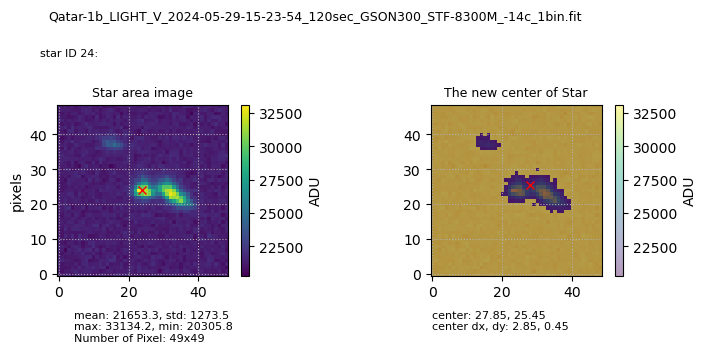

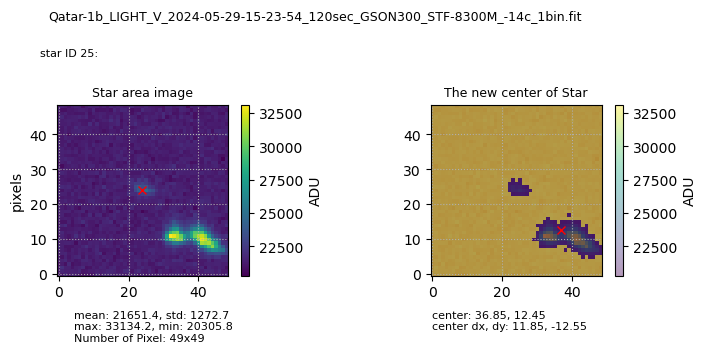

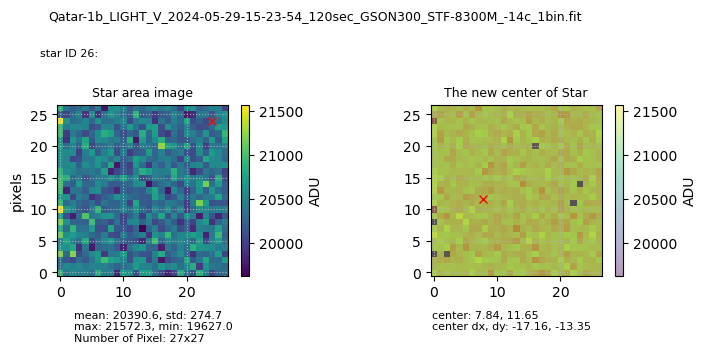

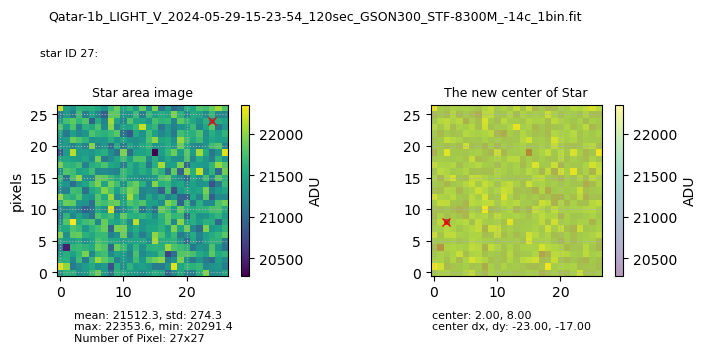

In [14]:
cutsizes = 49
for idx, row in df_apphot.iterrows():
    #1. cut asteroia area
    #print(idx)
    try :

        cut_hdu = Cutout2D(
                    data = hdul[0].data,
                    position = ((row['xcenter'],row['ycenter'])),
                    size=(cutsizes, cutsizes) #cut ccd
                    )
        avg, med, std = sigma_clipped_stats(cut_hdu.data)  # by default, 3-sigma 5-iteration.

        fig_set = plt.figure(figsize=(8, 5.5))
        
        ax11 = plt.subplot2grid((2, 2), (0,0),
                    fig=fig_set)
        #im11 = _tool_visualization.zimshow(ax11, cut_hdu.data)
        im11 = ax11.imshow(cut_hdu.data,
                        origin="lower")

        ax11.plot(round(cutsizes/2), round(cutsizes/2), 'rx')
        ax11.set_ylabel('pixels')
        ax11.grid(ls=':')
        ax11.set_title(f'Star area image', fontsize=9)
        ax11.annotate(   f"mean: {np.mean(cut_hdu.data):.01f}, std: {np.std(cut_hdu.data):.01f} \nmax: {np.max(cut_hdu.data):.01f}, min: {np.min(cut_hdu.data):.01f} \nNumber of Pixel: {np.shape(cut_hdu.data)[0]:.0f}x{np.shape(cut_hdu.data)[1]:.0f}",
            xy=(0, 0), xytext=(0.1, -0.20),
            xycoords='axes fraction',
            va='top', ha='left',
            fontsize=8)
        plt.colorbar(im11,
                    ax=ax11,
                    label="ADU",
                    fraction=0.0455, pad=0.04)
        #print("Image size is: ", cut_hdu.data.shape)

        #2. Get center dx, dy
        thresh_3sig = med + 3 * std
        mask_3sig = (cut_hdu.data < thresh_3sig)
        center = centroid_com(
                    data = cut_hdu.data,
                    mask = mask_3sig
                    )

        centerdx = center[0] - ((cutsizes+1)/2)
        centerdy = center[1] - ((cutsizes+1)/2)
        # print("type(center):", type(center))
        # print("center:", center)
        # print("center dx, dy:", centerdx, centerdy)

        ax12 = plt.subplot2grid((2,2), (0,1),
                    fig=fig_set)
        ax12.grid(ls=':')
        ax12.set_title(f'The new center of Star', fontsize=9)
        im12 = ax12.imshow(mask_3sig.astype(int),
            origin="lower")
        im12 = ax12.imshow(cut_hdu.data,
                alpha=0.4,
                origin="lower")
        ax12.plot(*center, 'rx')
        ax12.annotate(f"center: {center[0]:.02f}, {center[1]:.02f}\ncenter dx, dy: {centerdx:.02f}, {centerdy:.02f}",
                xy=(0, 0), xytext=(0.01, -0.20),
                xycoords='axes fraction',
                va='top', ha='left',
                fontsize=8)
        
        ax11.annotate(f"star ID {idx}: ",
                xy=(1, 0), xytext=(-0.1, 1.33),
                xycoords='axes fraction',
                va='top', ha='left',
                fontsize=8)
        
        plt.colorbar(im12,
                    ax=ax12,
                    label="ADU",
                    fraction=0.0455, pad=0.04)
        plt.suptitle(f"{fpath.name}", 
                    fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f"{INSTRESULTDIR/fpath.stem}_Star_{idx:03d}.png")
        # plt.show()
        # plt.close()
    except : 
        continue

In [15]:
#Returns magnitude from flux.
def mag_inst(flux, ferr):
    m_inst = -2.5 * np.log10(flux)
    merr   = 2.5/ np.log(10) * ferr / flux
    return m_inst, merr

In [16]:
# since our `annul` has many elements,
mask_apert = (apert.to_mask(method='center'))
mask_annul = (annul.to_mask(method='center'))

mag_ann  = np.zeros(len(apphot_result))
merr_ann = np.zeros(len(apphot_result))

In [17]:
for i in range(len(apphot_result)):
    annul_weighted = mask_annul[i].multiply(hdul[0].data)
    sky_non0   = np.nonzero(annul_weighted)
    sky_pixel  = annul_weighted[sky_non0]
    
    msky, sky_std, nsky, nrej = _astro_utilities.sky_fit(sky_pixel, method='mode', 
                                                        mode_option='sex')

    flux_star = apphot_result['aperture_sum'][i] - msky * ap_area  # total - sky

    flux_err  = np.sqrt(apphot_result['aperture_sum'][i] * gain    # Poissonian (star + sky)
                        + ap_area * rdnoise**2 # Gaussian
                        + (ap_area * (gain * sky_std))**2 / nsky )

    mag_ann[i], merr_ann[i] = mag_inst(flux_star, flux_err)
    df_apphot.at[i, 'msky'] = msky
    df_apphot.at[i, 'sky_std'] = sky_std
    df_apphot.at[i, 'nsky'] = nsky
    df_apphot.at[i, 'nrej'] = nrej
    df_apphot.at[i, 'flux_star'] = flux_star
    df_apphot.at[i, 'flux_err'] = flux_err
    df_apphot.at[i, 'mag_ann'] = mag_ann[i]
    df_apphot.at[i, 'merr_ann'] = merr_ann[i]

sky = wcs.pixel_to_world(df_apphot['xcenter'], df_apphot['ycenter'])
sky
# df_apphot.to_csv(f"{INSTRESULTDIR}/{fpath.stem}_m_inst.csv")
df_apphot

/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/667645571.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_119037/66

,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,flux_err,mag_ann,merr_ann
0,1,2.149246,2.210096,2.488427e+06,20793.598039,258.241298,627.0,3.0,-2.802899e+06,1373.174550,NaN,-0.000532
1,2,3348.806514,2.182796,2.615575e+06,21821.590050,263.115684,624.0,5.0,-2.937343e+06,1404.738188,NaN,-0.000519
2,3,2273.135106,83.970840,5.540104e+06,21943.710800,264.648702,2258.0,5.0,-4.389030e+04,1531.933325,NaN,-0.037896
3,4,2280.357051,83.576623,5.659092e+06,21932.658162,264.283773,2257.0,7.0,7.791053e+04,1546.030098,-12.228990,0.021545
4,5,1596.978322,406.939244,5.473357e+06,21493.960593,244.564847,2256.0,6.0,3.810392e+03,1510.688776,-8.952424,0.430457
5,6,2956.103799,554.240884,5.597878e+06,21854.296869,256.429886,2254.0,5.0,3.663644e+04,1533.571146,-11.409783,0.045448
6,7,2490.061386,816.225203,5.583824e+06,21661.796117,248.676364,2247.0,13.0,7.156790e+04,1527.087195,-12.136796,0.023167
7,8,2482.558206,816.710057,5.626655e+06,21664.905542,252.773930,2257.0,9.0,1.136078e+05,1534.546282,-12.638521,0.014665
8,9,1197.792379,881.221714,5.522376e+06,21481.165924,243.547292,2258.0,5.0,5.608501e+04,1515.968134,-11.872117,0.029347
9,10,1568.094387,926.207732,5.475324e+06,21459.415586,248.703111,2250.0,5.0,1.456829e+04,1513.795799,-10.408521,0.112819


In [18]:
# for i, row in df_apphot.iterrows():
#     annul_weighted = mask_annul[i].multiply(hdul[0].data)
#     sky_non0   = np.nonzero(annul_weighted)
#     sky_pixel  = annul_weighted[sky_non0]
#     msky, sky_std, nsky, nrej = _astro_utilities.sky_fit(sky_pixel, method='mode', mode_option='sex')

#     flux_star = apphot_result['aperture_sum'][i] - msky * ap_area  # total - sky

#     flux_err  = np.sqrt(apphot_result['aperture_sum'][i] * gain    # Poissonian (star + sky)
#                         + ap_area * rdnoise**2 # Gaussian
#                         + (ap_area * (gain * sky_std))**2 / nsky )

#     mag_ann, merr_ann = mag_inst(flux_star, flux_err)
#     df_apphot.loc[i, 'msky'] = msky
#     df_apphot.loc[i, 'sky_std'] = sky_std
#     df_apphot.loc[i, 'nsky'] = nsky
#     df_apphot.loc[i, 'nrej'] = nrej
#     df_apphot.loc[i, 'flux_star'] = flux_star
#     df_apphot.loc[i, 'flux_err'] = flux_err
#     df_apphot.loc[i, 'mag_inst'] = mag_ann
#     df_apphot.loc[i, 'merr_inst'] = merr_ann

# df_apphot.to_csv(f"{INSTRESULTDIR}/{fpath.stem}_m_inst.csv")
# df_apphot

In [19]:
df_apphot_sub = df_apphot.dropna()
df_apphot_sub

,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,flux_err,mag_ann,merr_ann
3,4,2280.357051,83.576623,5.659092e+06,21932.658162,264.283773,2257.0,7.0,77910.532383,1546.030098,-12.228990,0.021545
4,5,1596.978322,406.939244,5.473357e+06,21493.960593,244.564847,2256.0,6.0,3810.391820,1510.688776,-8.952424,0.430457
5,6,2956.103799,554.240884,5.597878e+06,21854.296869,256.429886,2254.0,5.0,36636.435363,1533.571146,-11.409783,0.045448
6,7,2490.061386,816.225203,5.583824e+06,21661.796117,248.676364,2247.0,13.0,71567.896364,1527.087195,-12.136796,0.023167
7,8,2482.558206,816.710057,5.626655e+06,21664.905542,252.773930,2257.0,9.0,113607.823854,1534.546282,-12.638521,0.014665
8,9,1197.792379,881.221714,5.522376e+06,21481.165924,243.547292,2258.0,5.0,56085.008039,1515.968134,-11.872117,0.029347
9,10,1568.094387,926.207732,5.475324e+06,21459.415586,248.703111,2250.0,5.0,14568.285252,1513.795799,-10.408521,0.112819
10,11,2011.915327,947.754972,5.546923e+06,21515.894767,252.122337,2254.0,6.0,71794.301169,1524.588969,-12.140225,0.023056
12,13,1370.152858,1412.532478,5.552826e+06,21382.942512,243.180344,2264.0,4.0,111530.269367,1519.246379,-12.618482,0.014790
13,14,2590.058296,1696.147383,5.553630e+06,21467.711200,248.068848,2257.0,7.0,90762.906217,1522.680993,-12.394771,0.018215


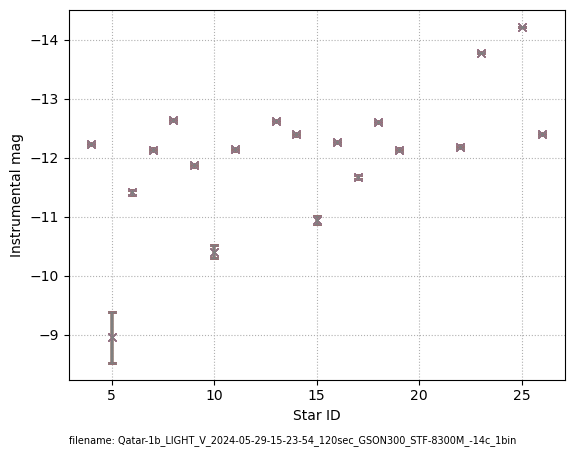

In [20]:
df_apphot_sub = df_apphot.dropna()

fig, ax = plt.subplots()

for idx, row in df_apphot.iterrows():

    ax.errorbar(df_apphot_sub["id"], 
                df_apphot_sub["mag_ann"], yerr=df_apphot_sub["merr_ann"],
                marker='x',
                ls='none',
                #ms=10,
                capsize=3)

ax.invert_yaxis()
# ax.set_ylim(ymin=-20, ymax=0)

ax.annotate(f'filename: {fpath.stem}', fontsize=7,
    xy=(0, 0), xytext=(0, -40), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

plt.xlabel('Star ID')
plt.ylabel('Instrumental mag')
plt.grid(ls=':')

plt.savefig(f"{INSTRESULTDIR}/{fpath.stem}_m_inst_chart.png")
plt.show()
# plt.close()

In [21]:
sky_coord = wcs.pixel_to_world(df_apphot['xcenter'], df_apphot['ycenter'])
sky_coord
print(type(sky_coord))
#sky_coord[0]

dir(sky_coord)
len(sky_coord.ra)
# df_apphot["RA2000"] = sky_coord.ra
# df_apphot["RA2000"]
df_RADEC = pd.DataFrame({"RA2000": sky_coord.ra.degree, "DEC2000": sky_coord.dec.degree})
df_RADEC
#type(df_RADEC["RA2000"][0])

<class 'astropy.coordinates.sky_coordinate.SkyCoord'>


,RA2000,DEC2000
0,304.405913,65.504040
1,302.351135,65.480215
2,303.012510,65.470048
3,303.008073,65.470087
4,303.432751,65.393014
5,302.605576,65.343917
6,302.895639,65.281681
7,302.900218,65.281625
8,303.683829,65.274708
9,303.459008,65.260917


In [22]:
df_apphot = pd.concat([df_apphot, df_RADEC], axis=1,)
df_apphot['filename'] = fpath.stem
df_apphot['t_start'] = t_start
df_apphot['t_expos'] = t_expos
df_apphot['t_middle'] = t_middle

df_apphot.to_csv(f"{INSTRESULTDIR}/{fpath.stem}_m_inst.csv")
df_apphot

,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,flux_err,mag_ann,merr_ann,RA2000,DEC2000,t_start
0,1,2.149246,2.210096,2.488427e+06,20793.598039,258.241298,627.0,3.0,-2.802899e+06,1373.174550,NaN,-0.000532,304.405913,65.504040,2024-05-29T15:23:54.621
1,2,3348.806514,2.182796,2.615575e+06,21821.590050,263.115684,624.0,5.0,-2.937343e+06,1404.738188,NaN,-0.000519,302.351135,65.480215,2024-05-29T15:23:54.621
2,3,2273.135106,83.970840,5.540104e+06,21943.710800,264.648702,2258.0,5.0,-4.389030e+04,1531.933325,NaN,-0.037896,303.012510,65.470048,2024-05-29T15:23:54.621
3,4,2280.357051,83.576623,5.659092e+06,21932.658162,264.283773,2257.0,7.0,7.791053e+04,1546.030098,-12.228990,0.021545,303.008073,65.470087,2024-05-29T15:23:54.621
4,5,1596.978322,406.939244,5.473357e+06,21493.960593,244.564847,2256.0,6.0,3.810392e+03,1510.688776,-8.952424,0.430457,303.432751,65.393014,2024-05-29T15:23:54.621
5,6,2956.103799,554.240884,5.597878e+06,21854.296869,256.429886,2254.0,5.0,3.663644e+04,1533.571146,-11.409783,0.045448,302.605576,65.343917,2024-05-29T15:23:54.621
6,7,2490.061386,816.225203,5.583824e+06,21661.796117,248.676364,2247.0,13.0,7.156790e+04,1527.087195,-12.136796,0.023167,302.895639,65.281681,2024-05-29T15:23:54.621
7,8,2482.558206,816.710057,5.626655e+06,21664.905542,252.773930,2257.0,9.0,1.136078e+05,1534.546282,-12.638521,0.014665,302.900218,65.281625,2024-05-29T15:23:54.621
8,9,1197.792379,881.221714,5.522376e+06,21481.165924,243.547292,2258.0,5.0,5.608501e+04,1515.968134,-11.872117,0.029347,303.683829,65.274708,2024-05-29T15:23:54.621
9,10,1568.094387,926.207732,5.475324e+06,21459.415586,248.703111,2250.0,5.0,1.456829e+04,1513.795799,-10.408521,0.112819,303.459008,65.260917,2024-05-29T15:23:54.621


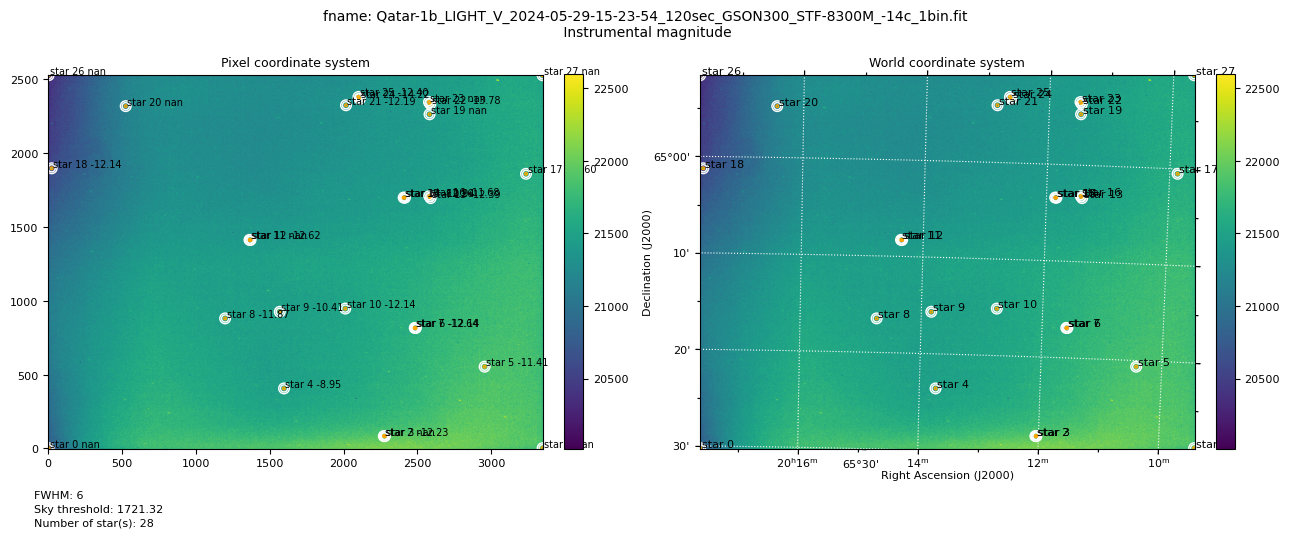

In [179]:
fig_set = plt.figure(figsize=val_figsize)

ax1 = plt.subplot2grid((1,2), (0,0),
                    fig=fig_set)
im1 = _tool_visualization.zimshow(ax1, hdul[0].data, )
ax1.set_title('Pixel coordinate system', fontsize=9)
ax1.tick_params(labelsize=8)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)
im2 = _tool_visualization.zimshow(ax2, hdul[0].data, )

for i, row in df_apphot.iterrows():
    ap = CAp((row['xcenter'], row['ycenter']), r=R_AP)
    an = CAn((row['xcenter'], row['ycenter']), r_in=R_IN, r_out=R_OUT)
    ax1.text(row['xcenter']+10, row['ycenter']+10, f"star {i} {row['mag_ann']:.02f}", fontsize=7)
    ap.plot(ax1, color="orange")
    an.plot(ax1, color="w")
    ax2.text(row['xcenter']+10, row['ycenter']+10, f"star {i}", fontsize=8)
    ap.plot(ax2, color="orange")
    an.plot(ax2, color="w")

ax2.set_title('World coordinate system', fontsize=9)
ax2.coords.grid(True, color='white', ls=':')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)', minpad=0.5, fontsize=8)
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)', minpad=0.4, fontsize=8)
ax2.coords['dec'].set_ticklabel_position('bl')
ax2.coords['ra'].set_major_formatter('hh:mm')
ax2.coords['dec'].set_major_formatter('dd:mm')
ax2.coords['ra'].display_minor_ticks(True)
ax2.coords['dec'].display_minor_ticks(True)
ax2.coords['ra'].set_minor_frequency(2)
ax2.coords['dec'].set_minor_frequency(2)
ax2.tick_params(labelsize=8)

cbar1 = plt.colorbar(im1, ax = ax1, fraction=val_fraction, pad=0.04)
cbar2 = plt.colorbar(im2, ax = ax2, fraction=val_fraction, pad=0.04, )
cbar1.ax.tick_params(labelsize=8)
cbar2.ax.tick_params(labelsize=8)

plt.suptitle(f"fname: {fpath.name}\n Instrumental magnitude", fontsize=10,)

ax1.annotate(f'FWHM: {FWHM}', fontsize=8,
    xy=(0, 0), xytext=(-10, -30), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

ax1.annotate(f'Sky threshold: {thresh:.02f}', fontsize=8,
    xy=(0, 0), xytext=(-10, -40), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

ax1.annotate(f'Number of star(s): {len(DAOfound)}', fontsize=8,
    xy=(0, 0), xytext=(-10, -50), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

plt.tight_layout()
plt.savefig(f"{INSTRESULTDIR}/{fpath.stem}_M_inst.png")

# plt.show()
# plt.close()